# NASA VERİLERİ İLE DÜNYA'YA YAKIN NESNELERİN (NEO) İSTATİSTİKSEL RAPORU

Proje Sahibi: Senanur AVCIL

## 1. VERİ SETİ TANITIMI
Bu rapor, NASA tarafından sağlanan ve Dünya'ya yakın geçiş yapan asteroitlere (Near-Earth Objects - NEO) ait veri setini incelemektedir. Projenin amacı, gök cisimlerinin fiziksel özellikleri ile hareket dinamikleri arasındaki ilişkileri istatistiksel ve görsel yöntemlerle analiz etmektir.

* **Veri Kaynağı:** Veri seti, Kaggle platformunda yayınlanan "NASA - Nearest Earth Objects" veri setinden elde edilmiştir. Veri setinin temel kaynağı NASA'nın Near Earth Object (NEO) verileri ve NASA Jet Propulsion Laboratory (JPL) tarafından sağlanan açık uzay verileridir.
* **Orijinal Veri Boyutu:** 90.836 satır ve 10 sütun
* **Çalışılan Örneklem Boyutu:** Rastgele seçilen örneklem **5.000 satır**.
* **İncelenen Temel Sütunlar:** Minimum Çap (km), Maksimum Çap (km), Göreceli Hız (km/saat), Teğet Geçme Mesafesi (km), Mutlak Parlaklık, Tehlike Durumu.

### ÖZET VE GENEL BULGULAR
​Bu proje kapsamında, NASA tarafından sağlanan Dünya'ya yakın nesnelere (NEO) ait 5.000 gözlemlik örneklem üzerinde yapılan tüm betimsel istatistikler, çapraz tablolar ve görsel analizler sonucunda şu 3 temel akademik bulguya ulaşılmıştır:

**​1. Kütle ve Boyut Asimetrisi (Küçük Cisim Yoğunluğu):** Veri setinde modun minimum çapın 0.035 km çıkması ve dağılımın yüksek bir pozitif çarpıklık sergilemesi, Dünya yakınındaki asteroit popülasyonunun bir çoğunluğunun küçük kütlelerden oluştuğunu kanıtlamaktadır. Ancak değişim aralığının 23 km gibi büyük bir değere sahip olması, nadir de olsa ortalamayı yukarı çeken uç değerlerin varlığını ve risk takibinin neden önemli olduğunu ortaya koymaktadır.

**​2. Risk Sınıflandırmasının Dinamik Karakteri:** Yapılan frekans analizinde asteroitlerin %91.1'inin güvenli, %8.9'unun ise tehlikeli sınıfta olduğu tespit edilmiştir. Yapılan groupby analizi ve keman grafiği görselleştirmesi, bu iki grubun rastgele dağılmadığını; potansiyel olarak tehlikeli (True) olarak sınıflandırılan asteroitlerin, güvenli olanlara kıyasla hem fiziksel çap olarak daha büyük (ortalama 0.291 km) hem de göreceli hız olarak bariz şekilde daha süratli (ortalama 66.948 km/saat) hareket ettiğini bilimsel olarak doğrulamaktadır.

**​3. Fiziksel Özelliklerin Doğrusal Olmayan Bağımlılığı:** Asteroitlerin fiziksel boyutları ile uzaydaki görünürlük dereceleri arasında doğrusal olmayan güçlü bir bağ vardır. Serpme grafiği analizinde net bir şekilde gözlemlendiği üzere, asteroitlerin geometrik çapı büyüdükçe mutlak parlaklık (magnitude) değerleri azalmaktadır. Astronomi literatüründeki "küçük magnitude = daha büyük ve parlak cisim" kuralı, yapılan bu korelasyon ve görsel analiz çalışmasıyla istatistiksel olarak doğrulanmıştır.

## Sütun Açıklamaları
Veri setinde yer alan ve analiz boyunca kullanılacak temel değişkenlerin yapısal tanımları aşağıda belirtilmiştir:

* **id / name:** Her bir gök cisminin tanımlayıcısı ve NASA tarafından verilen resmi adı.
* **est_diameter_min / est_diameter_max:** Gök cisminin kilometre cinsinden hesaplanan tahmini minimum ve maksimum fiziksel boyutu.
* **relative_velocity:** Nesnenin Dünya'nın yörüngesinden geçerken sahip olduğu anlık hız değeri.
* **miss_distance:** Gök cisminin Dünya yüzeyine en çok yaklaştığı anda, aradaki ıskalama mesafesi.
* **absolute_magnitude:** Nesnenin içsel parlaklık ölçüsü.
* **hazardous:** Nesnenin Dünya için potansiyel bir tehdit oluşturup oluşturmadığını belirten mantıksal değişken (True/False).

In [1]:
import pandas as pd             # Filtreleme ve tablo işlemleri için kullanılacak.
import numpy as np              # Gelişmiş matematiksel hesaplamalar için kullanılacak.
import matplotlib.pyplot as plt # Temel, statik ve geleneksel veri görselleştirme grafikleri için kullanılacak.
import seaborn as sns           # Matplotlib tabanlı, istatistiksel ve daha şık statik grafikler için kullanılacak.
import plotly.express as px     # Canlı raporda, etkileşimli grafikler için kullanılacak.

In [2]:
# Veri setini data klasöründen okuma
df_orijinal = pd.read_csv("C:/Users/SENANUR AVCIL/projelerim/vabp_denemeleri/nasa_neo_analizi/data/nasa_neo_data.csv")

# Veri setini optimize etmek için rastgele 5000 satır örnekleme alma
df = df_orijinal.sample(n=5000, random_state=42).reset_index(drop=True)

In [3]:
# Yüklenen verilerin boyutunun kontrolü
print(f"Orijinal Veri Boyutu    : {df_orijinal.shape}")
print(f"Örneklenmiş Veri Boyutu : {df.shape}")

Orijinal Veri Boyutu    : (90836, 10)
Örneklenmiş Veri Boyutu : (5000, 10)


In [4]:
print("Boyut:", df.shape)
print("\nSütunlar:", df.columns.tolist())
print("\nVeri Tipleri:\n", df.dtypes)
print("\nEksik Değerler:\n", df.isnull().sum())

Boyut: (5000, 10)

Sütunlar: ['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous']

Veri Tipleri:
 id                      int64
name                      str
est_diameter_min      float64
est_diameter_max      float64
relative_velocity     float64
miss_distance         float64
orbiting_body             str
sentry_object            bool
absolute_magnitude    float64
hazardous                bool
dtype: object

Eksik Değerler:
 id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64


In [5]:
# Verinin ilk 5 satırını ekrana getirme:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,3943344,(2019 YT1),0.024241,0.054205,22148.962596,5.028574e+07,Earth,False,25.20,False
1,3879239,(2019 US),0.012722,0.028447,26477.211836,1.683201e+06,Earth,False,26.60,False
2,3879244,(2019 UU),0.013322,0.029788,33770.201397,3.943220e+06,Earth,False,26.50,False
3,2481965,481965 (2009 EB1),0.193444,0.432554,43599.575296,7.346837e+07,Earth,False,20.69,False
4,3789471,(2017 WJ1),0.044112,0.098637,36398.080883,6.352916e+07,Earth,False,23.90,False


In [6]:
# Sütun isimlerinin başındaki ve sonundaki boşlukları temizleme
df.columns = df.columns.str.strip()

# Tüm sütunları Türkçe'ye çevirme ve df'e kaydetme
df = df.rename(columns={
    "id": "ID Numarası",
    "name": "Asteroit Adı",
    "est_diameter_min": "Minimum Çap (km)",
    "est_diameter_max": "Maksimum Çap (km)",
    "relative_velocity": "Göreceli Hız (km/saat)",
    "miss_distance": "Teğet Geçme Mesafesi (km)",
    "orbiting_body": "Yörüngesinde Olduğu Cisim",
    "sentry_object": "Sentry İzleme Nesnesi",
    "absolute_magnitude": "Mutlak Parlaklık",
    "hazardous": "Tehlike Durumu"
})

df.head()

,ID Numarası,Asteroit Adı,Minimum Çap (km),Maksimum Çap (km),Göreceli Hız (km/saat),Teğet Geçme Mesafesi (km),Yörüngesinde Olduğu Cisim,Sentry İzleme Nesnesi,Mutlak Parlaklık,Tehlike Durumu
0,3943344,(2019 YT1),0.024241,0.054205,22148.962596,5.028574e+07,Earth,False,25.20,False
1,3879239,(2019 US),0.012722,0.028447,26477.211836,1.683201e+06,Earth,False,26.60,False
2,3879244,(2019 UU),0.013322,0.029788,33770.201397,3.943220e+06,Earth,False,26.50,False
3,2481965,481965 (2009 EB1),0.193444,0.432554,43599.575296,7.346837e+07,Earth,False,20.69,False
4,3789471,(2017 WJ1),0.044112,0.098637,36398.080883,6.352916e+07,Earth,False,23.90,False


In [7]:
# Tanımsal İstatistiklerin Hesaplanması
print("Tanımsal İstatistik Hesaplamaları")

# Aritmetik ortalama hesaplamaları
hiz_ortalama = df["Göreceli Hız (km/saat)"].mean()
cap_min_ortalama = df["Minimum Çap (km)"].mean()
cap_maks_ortalama = df["Maksimum Çap (km)"].mean()
teget_gecme_ortalama = df["Teğet Geçme Mesafesi (km)"].mean()
parlaklik_ortalama = df["Mutlak Parlaklık"].mean()

print(f"Asteroitlerin Göreceli Hızının Ortalaması        : {hiz_ortalama:,.3f} km/saat")
print(f"Asteroitlerin Minimum Çapının Ortalaması         : {cap_min_ortalama:,.3f} km")
print(f"Asteroitlerin Maksimum Çapının Ortalaması        : {cap_maks_ortalama:,.3f} km")
print(f"Asteroitlerin Teğet Geçme Mesafesinin Ortalaması : {teget_gecme_ortalama:,.3f} km")
print(f"Asteroitlerin Parlaklığının Ortalaması           : {parlaklik_ortalama:,.3f} Magnitude")

Tanımsal İstatistik Hesaplamaları
Asteroitlerin Göreceli Hızının Ortalaması        : 48,348.382 km/saat
Asteroitlerin Minimum Çapının Ortalaması         : 0.135 km
Asteroitlerin Maksimum Çapının Ortalaması        : 0.302 km
Asteroitlerin Teğet Geçme Mesafesinin Ortalaması : 37,595,127.142 km
Asteroitlerin Parlaklığının Ortalaması           : 23.558 Magnitude


Hesaplanan aritmetik ortalama çıktıları incelendiğinde, veri setindeki asteroitlerin genel fiziksel ve hareket karakteristikleri şu şekildedir:
1. Hız ve Mesafe Durumu: Asteroitlerin ortalama göreceli hızları yaklaşık 48.348 km/saat gibi oldukça yüksek bir sürate sahipken, Dünya'ya teğet geçme mesafelerinin ortalaması ise yaklaşık 37.595.127 km olarak hesaplanmıştır. Bu durum, nesnelerin genel olarak Dünya'dan astronomik açıdan güvenli sayılabilecek uzaklıklardan geçtiğini göstermektedir.

2. Boyut ve Parlaklık Yapısı: Nesnelerin ortalama minimum çapı 0.135 km, ortalama maksimum çapı ise 0.302 km düzeyindedir. Bu küçük boyut yapısına paralel olarak, asteroitlerin parlaklık derecesini gösteren mutlak parlaklık ortalaması da 23.558 Magnitude olarak bulunmuştur. Astronomide bu değerin yüksek olması, nesnelerin fiziksel olarak küçük ve daha az görünür olduğunu doğrulamaktadır.

In [8]:
# Medyan hesaplamaları
hiz_medyan = df["Göreceli Hız (km/saat)"].median()
cap_min_medyan = df["Minimum Çap (km)"].median()
cap_maks_medyan = df["Maksimum Çap (km)"].median()
teget_gecme_medyan = df["Teğet Geçme Mesafesi (km)"].median()
parlaklik_medyan = df["Mutlak Parlaklık"].median()

print(f"Asteroitlerin Göreceli Hız Medyanı            : {hiz_medyan:,.3f} km/saat")
print(f"Asteroitlerin Minimum Çapının Medyanı         : {cap_min_medyan:,.3f} km")
print(f"Asteroitlerin Maksimum Çapının Medyanı        : {cap_maks_medyan:,.3f} km")
print(f"Asteroitlerin Teğet Geçme Mesafesinin Medyanı : {teget_gecme_medyan:,.3f} km")
print(f"Asteroitlerin Parlaklığının Medyanı           : {parlaklik_medyan:,.3f} Magnitude")

Asteroitlerin Göreceli Hız Medyanı            : 44,790.467 km/saat
Asteroitlerin Minimum Çapının Medyanı         : 0.046 km
Asteroitlerin Maksimum Çapının Medyanı        : 0.103 km
Asteroitlerin Teğet Geçme Mesafesinin Medyanı : 38,814,227.691 km
Asteroitlerin Parlaklığının Medyanı           : 23.800 Magnitude


Veri setindeki asteroitler için medyan sonuçları incelenmiştir. Asteroitlerin medyan hızı yaklaşık 44.791 km/saat ve Dünya'ya teğet geçme mesafesi medyanı ise yaklaşık 38.814.228 km olarak hesaplanmıştır. Fiziksel boyutlarda ise nesnelerin yarısının 0,046 km'den daha küçük minimum çapa sahip olduğu görülmektedir. Medyan değerlerinin aritmetik ortalamalardan görece daha düşük olması, veri setinde ortalamayı yukarı çeken bazı uç değerli asteroitlerin varlığına işaret etmektedir.

In [9]:
# Sürekli değişkenlerde mod direkt gelmeyebilir veya birden fazla olabilir, bu yüzden .iloc[0] ile ilk modu alıyoruz.
hiz_mod = df["Göreceli Hız (km/saat)"].mode().iloc[0]
cap_min_mod = df["Minimum Çap (km)"].mode().iloc[0]
cap_maks_mod = df["Maksimum Çap (km)"].mode().iloc[0]
teget_gecme_mod = df["Teğet Geçme Mesafesi (km)"].mode().iloc[0]
parlaklik_mod = df["Mutlak Parlaklık"].mode().iloc[0]

print(f"Asteroitlerin Göreceli Hızının Modu        : {hiz_mod:,.3f} km/saat")
print(f"Asteroitlerin Minimum Çapının Modu         : {cap_min_mod:,.3f} km")
print(f"Asteroitlerin Maksimum Çapının Modu        : {cap_maks_mod:,.3f} km")
print(f"Asteroitlerin Teğet Geçme Mesafesinin Modu : {teget_gecme_mod:,.3f} km")
print(f"Asteroitlerin Parlaklığının Modu           : {parlaklik_mod:,.3f} Magnitude")

Asteroitlerin Göreceli Hızının Modu        : 2,022.487 km/saat
Asteroitlerin Minimum Çapının Modu         : 0.035 km
Asteroitlerin Maksimum Çapının Modu        : 0.078 km
Asteroitlerin Teğet Geçme Mesafesinin Modu : 10,980,791.889 km
Asteroitlerin Parlaklığının Modu           : 24.400 Magnitude


Veri setindeki mod değerleri, nesnelerin tipik yoğunlaşma noktalarını göstermektedir. Analiz sonuçlarına göre asteroitlerin en yaygın bulunan minimum çap boyutu 0,035 km ve en sık tekrar eden mutlak parlaklık seviyesi 24,4 Magnitude olarak hesaplanmıştır. Sürekli sayısal bir değişken olan göreceli hızda ise en çok tekrarlanan ilk değer yaklaşık 2.023 km/saat olarak kayıtlara geçmiştir. Bu duruma göre; veri setinde fiziksel olarak küçük, sönük ve başlangıç hız seviyelerinde kümelenen yoğun bir asteroit grubu bulunduğunu doğrulamaktadır.

In [10]:
print("Değişkenlik Ölçüleri")
# Standart Sapma hesaplamaları
hiz_std = df["Göreceli Hız (km/saat)"].std()
cap_min_std = df["Minimum Çap (km)"].std()
cap_maks_std = df["Maksimum Çap (km)"].std()
teget_gecme_std = df["Teğet Geçme Mesafesi (km)"].std()
parlaklik_std = df["Mutlak Parlaklık"].std()

print(f"Asteroitlerin Göreceli Hızının Standart Sapması        : {hiz_std:,.3f} km/saat")
print(f"Asteroitlerin Minimum Çapının Standart Sapması         : {cap_min_std:,.3f} km")
print(f"Asteroitlerin Maksimum Çapının Standart Sapması        : {cap_maks_std:,.3f} km")
print(f"Asteroitlerin Teğet Geçme Mesafesinin Standart Sapması : {teget_gecme_std:,.3f} km")
print(f"Asteroitlerin Parlaklığının Standart Sapması           : {parlaklik_std:,.3f} Magnitude")
print(f"-----------------------------------------------------------------------------------")

# Varyans hesaplamaları
hiz_varyans = df["Göreceli Hız (km/saat)"].var()
cap_min_varyans = df["Minimum Çap (km)"].var()
cap_maks_varyans = df["Maksimum Çap (km)"].var()
teget_gecme_varyans = df["Teğet Geçme Mesafesi (km)"].var()
parlaklik_varyans = df["Mutlak Parlaklık"].var()

print(f"Asteroitlerin Göreceli Hızının Varyansı        : {hiz_varyans:,.3f} km/saat")
print(f"Asteroitlerin Minimum Çapının Varyansı         : {cap_min_varyans:,.3f} km")
print(f"Asteroitlerin Maksimum Çapının Varyansı        : {cap_maks_varyans:,.3f} km")
print(f"Asteroitlerin Teğet Geçme Mesafesinin Varyansı : {teget_gecme_varyans:,.3f} km")
print(f"Asteroitlerin Parlaklığının Varyansı           : {parlaklik_varyans:,.3f} Magnitude")

Değişkenlik Ölçüleri
Asteroitlerin Göreceli Hızının Standart Sapması        : 25,308.188 km/saat
Asteroitlerin Minimum Çapının Standart Sapması         : 0.519 km
Asteroitlerin Maksimum Çapının Standart Sapması        : 1.160 km
Asteroitlerin Teğet Geçme Mesafesinin Standart Sapması : 22,525,263.369 km
Asteroitlerin Parlaklığının Standart Sapması           : 2.899 Magnitude
-----------------------------------------------------------------------------------
Asteroitlerin Göreceli Hızının Varyansı        : 640,504,381.008 km/saat
Asteroitlerin Minimum Çapının Varyansı         : 0.269 km
Asteroitlerin Maksimum Çapının Varyansı        : 1.346 km
Asteroitlerin Teğet Geçme Mesafesinin Varyansı : 507,387,489,822,760.250 km
Asteroitlerin Parlaklığının Varyansı           : 8.406 Magnitude


Verilerin aritmetik ortalamadan ne kadar uzaklaştığını ve risk derecesini gösteren değişkenlik ölçüleri hesaplanmıştır. Göreceli hız değişkenindeki yaklaşık 25.308 km/saat'lik standart sapma ve yüksek varyansı, asteroit süratlerinin geniş bir şekilde farklılaştığını ortaya koymaktadır. Benzer şekilde, Teğet Geçme mesafesi standart sapmasının yaklaşık 22.525.263 km gibi yüksek bir değere sahip olması, nesnelerin Dünya'ya yakınlık derecelerinin son derece değişken olduğunu göstermektedir. Mutlak parlaklık standart sapmasının ise sadece 2,899 Magnitude çıkması, parlaklık ölçümlerinin ortalama etrafında daha kararlı ve birbirine yakın değerlerden oluştuğunu kanıtlamaktadır.

In [11]:
# Değişim Aralığı hesaplamaları
hiz_range = df["Göreceli Hız (km/saat)"].max() - df["Göreceli Hız (km/saat)"].min()
cap_min_range = df["Minimum Çap (km)"].max() - df["Minimum Çap (km)"].min()  # Minimum çaptaki maksimum değer
cap_maks_range = df["Maksimum Çap (km)"].max() - df["Maksimum Çap (km)"].min()
teget_gecme_range = df["Teğet Geçme Mesafesi (km)"].max() - df["Teğet Geçme Mesafesi (km)"].min()
parlaklik_range = df["Mutlak Parlaklık"].max() - df["Mutlak Parlaklık"].min()

print(f"Asteroitlerin Göreceli Hızının Değişim Aralığı        : {hiz_range:,.3f} km/saat")
print(f"Asteroitlerin Minimum Çapının Değişim Aralığı         : {cap_min_range:,.3f} km")
print(f"Asteroitlerin Maksimum Çapının Değişim Aralığı        : {cap_maks_range:,.3f} km")
print(f"Asteroitlerin Teğet Geçme Mesafesinin Değişim Aralığı : {teget_gecme_range:,.3f} km")
print(f"Asteroitlerin Parlaklığının Değişim Aralığı           : {parlaklik_range:,.3f} Magnitude")

Asteroitlerin Göreceli Hızının Değişim Aralığı        : 189,153.971 km/saat
Asteroitlerin Minimum Çapının Değişim Aralığı         : 23.043 km
Asteroitlerin Maksimum Çapının Değişim Aralığı        : 51.525 km
Asteroitlerin Teğet Geçme Mesafesinin Değişim Aralığı : 74,755,944.192 km
Asteroitlerin Parlaklığının Değişim Aralığı           : 21.390 Magnitude


Her bir değişkenin maksimum ve minimum değeri arasındaki mesafeyi ölçen değişim aralığı sonuçları, verinin toplam yayılım sınırlarını göstermektedir. Asteroitlerin göreceli hızları en yavaş ile en hızlı nesne arasında yaklaık 189.154 km/saat'lik devasa bir uçurum barındırmaktadır. Dünya'ya en yakın ve en uzak geçen nesne arasındaki mesafe farkı ise yaklaşık 74.755.944 km gibi astronomik bir boyuttadır. Mutlak parlaklıkta ise en sönük nesne ile en parlak nesne arasında 21,39 Magnitude fark bulunmaktadır. Bu geniş aralıklar, veri setinin oldukça heterojen ve farklı karakterdeki gök cisimlerini bir arada barındıran zengin bir yapıya sahip olduğunu kanıtlar.

In [12]:
print("Kartiller (Çeyreklikler)")
# Çeyreklik hesaplamaları
hiz_q1 = df['Göreceli Hız (km/saat)'].quantile(0.25)
hiz_q3 = df['Göreceli Hız (km/saat)'].quantile(0.75)

print(f"Göreceli Hız %25. Çeyreklik (Q1) : {hiz_q1:,.3f} km/saat")
print(f"Göreceli Hız %75. Çeyreklik (Q3) : {hiz_q3:,.3f} km/saat")

Kartiller (Çeyreklikler)
Göreceli Hız %25. Çeyreklik (Q1) : 28,803.405 km/saat
Göreceli Hız %75. Çeyreklik (Q3) : 63,354.118 km/saat


Verilerin yüzde kaçlık dilimlerde nasıl kümelendiğini anlamak adına göreceli hız değişkeninin çeyreklik değerleri incelenmiştir. Hesaplamalara göre, asteroitlerin en yavaş %25'lik kesimini temsil eden birinci çeyreklik (Q1) sınırı yaklaşık 28.803 km/saat düzeyindedir. Nesnelerin %75'inin altında kaldığı üst hız sınırını gösteren üçüncü çeyreklik (Q3) değeri ise yaklaşık 63.354 km/saat olarak hesaplanmıştır. Bu iki değer arasındaki fark, asteroitlerin tam merkezindeki %50'lik ana gövdenin hız dağılım aralığını net bir şekilde ortaya koymaktadır.

In [13]:
# Çarpıklık (Skewness)
hiz_skew = df["Göreceli Hız (km/saat)"].skew()
cap_min_skew = df["Minimum Çap (km)"].skew()
cap_maks_skew = df["Maksimum Çap (km)"].skew()
teget_gecme_skew = df["Teğet Geçme Mesafesi (km)"].skew()
parlaklik_skew = df["Mutlak Parlaklık"].skew()

print(f"Asteroitlerin Göreceli Hızının Çarpıklık Değeri        : {hiz_skew:,.3f} km/saat")
print(f"Asteroitlerin Minimum Çapının Çarpıklık Değeri         : {cap_min_skew:,.3f} km")
print(f"Asteroitlerin Maksimum Çapının Çarpıklık Değeri        : {cap_maks_skew:,.3f} km")
print(f"Asteroitlerin Teğet Geçme Mesafesinin Çarpıklık Değeri : {teget_gecme_skew:,.3f} km")
print(f"Asteroitlerin Parlaklığının Çarpıklık Değeri           : {parlaklik_skew:,.3f} Magnitude")

Asteroitlerin Göreceli Hızının Çarpıklık Değeri        : 0.893 km/saat
Asteroitlerin Minimum Çapının Çarpıklık Değeri         : 35.209 km
Asteroitlerin Maksimum Çapının Çarpıklık Değeri        : 35.209 km
Asteroitlerin Teğet Geçme Mesafesinin Çarpıklık Değeri : -0.068 km
Asteroitlerin Parlaklığının Çarpıklık Değeri           : -0.233 Magnitude


Dağılımların simetriklik durumunu ölçen çarpıklık katsayıları incelenmiştir. Göreceli hız değişkeninin çarpıklık değeri 0,893 ile sıfıra yakın ve hafif pozitif olup, hız dağılımının görece dengeli ancak sağa doğru hafif kuyruklu bir yapıda olduğunu gösterir. Minimum çap değişkeninin 35,209 gibi aşırı yüksek ve pozitif bir çarpıklık değerine sahip olması, dağılımın çok güçlü bir şekilde sağa çarpık olduğunu kanıtlamaktadır. Bu durum istatistiksel olarak, veri setindeki asteroitlerin neredeyse tamamının çok küçük boyutlarda yığıldığını, çok az sayıdaki devasa asteroitin ise sağ tarafta çok uzun bir kuyruk oluşturduğunu belirtmektedir.

In [14]:
# Basıklık (Kurtosis)
hiz_kurtosis = df["Göreceli Hız (km/saat)"].kurtosis()
cap_min_kurtosis = df["Minimum Çap (km)"].kurtosis()
cap_maks_kurtosis = df["Maksimum Çap (km)"].kurtosis()
teget_gecme_kurtosis = df["Teğet Geçme Mesafesi (km)"].kurtosis()
parlaklik_kurtosis = df["Mutlak Parlaklık"].kurtosis()

print(f"Asteroitlerin Göreceli Hızının Basıklık Değeri        : {hiz_kurtosis:,.3f} km/saat")
print(f"Asteroitlerin Minimum Çapının Basıklık Değeri         : {cap_min_kurtosis:,.3f} km")
print(f"Asteroitlerin Maksimum Çapının Basıklık Değeri        : {cap_maks_kurtosis:,.3f} km")
print(f"Asteroitlerin Teğet Geçme Mesafesinin Basıklık Değeri : {teget_gecme_kurtosis:,.3f} km")
print(f"Asteroitlerin Parlaklığının Basıklık Değeri           : {parlaklik_kurtosis:,.3f} Magnitude")

Asteroitlerin Göreceli Hızının Basıklık Değeri        : 0.999 km/saat
Asteroitlerin Minimum Çapının Basıklık Değeri         : 1,523.301 km
Asteroitlerin Maksimum Çapının Basıklık Değeri        : 1,523.301 km
Asteroitlerin Teğet Geçme Mesafesinin Basıklık Değeri : -1.250 km
Asteroitlerin Parlaklığının Basıklık Değeri           : -0.370 Magnitude


Verilerin normal dağılıma kıyasla ne kadar sivri veya basık bir tepe oluşturduğunu gösteren basıklık katsayıları incelenmiştir. Göreceli hız basıklığı 0,999 ile normal dağılıma oldukça yakın bir tepe yapısı sunmaktadır. Teğet geçme mesafesi basıklığının -1,250 çıkması; bu dağılımın basık ve düz olduğunu, yani mesafelerin belirli bir merkezde toplanmayıp geniş bir alana yayıldığını gösterir. Ayrıca; minimum çap değişkeninin yaklaşık 1.523 gibi ekstrem düzeyde yüksek çıkan basıklık değeri, aşırı sivri ve dik bir yapıya işaret etmektedir. Bu yapı, asteroit boyutlarının çok dar ve spesifik bir alt sınır değerinde olağanüstü yüksek bir frekansla zirve yaptığını kanıtlamaktadır.

In [15]:
# Sayıları e'li gösterimden kurtarıp virgülden sonra 3 basamak yapma
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

desc_tr = df.describe().T

desc_tr = desc_tr.rename(columns={
    "count": "Gözlem Sayısı",
    "mean": "Ortalama",
    "std": "Standart Sapma",
    "min": "Minimum",
    "25%": "%25 (Q1)",
    "50%": "%50 (Medyan)",
    "75%": "%75 (Q3)",
    "max": "Maksimum",
    "range": "Değişim Aralığı"
})

# Değişim Aralığını (Range) hesaplayıp yeni sütun olarak ekleme
desc_tr['Değişim Aralığı (Range)'] = desc_tr['Maksimum'] - desc_tr['Minimum']

In [16]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

desc_tr

,Gözlem Sayısı,Ortalama,Standart Sapma,Minimum,%25 (Q1),%50 (Medyan),%75 (Q3),Maksimum,Değişim Aralığı (Range)
ID Numarası,5000.000,14316577.037,20821870.781,2000433.000,3466981.500,3748556.000,3883102.000,54272755.000,52272322.000
Minimum Çap (km),5000.000,0.135,0.519,0.001,0.019,0.046,0.139,23.044,23.043
Maksimum Çap (km),5000.000,0.302,1.160,0.003,0.041,0.103,0.312,51.528,51.525
Göreceli Hız (km/saat),5000.000,48348.382,25308.188,2022.487,28803.405,44790.467,63354.118,191176.458,189153.971
Teğet Geçme Mesafesi (km),5000.000,37595127.142,22525263.369,29217.945,17565301.421,38814227.691,57192631.709,74785162.137,74755944.192
Mutlak Parlaklık,5000.000,23.558,2.899,10.310,21.400,23.800,25.780,31.700,21.390


In [17]:
print("ÖZET TABLO")

satirlar = [
    "Göreceli Hız (km/saat)",
    "Minimum Çap (km)",
    "Maksimum Çap (km)",
    "Teğet Geçme Mesafesi (km)",
    "Mutlak Parlaklık (Magnitude)"
]

ozet_veri = {
    "Ortalama": [hiz_ortalama, cap_min_ortalama, cap_maks_ortalama, teget_gecme_ortalama, parlaklik_ortalama],
    "Medyan": [hiz_medyan, cap_min_medyan, cap_maks_medyan, teget_gecme_medyan, parlaklik_medyan],
    "Mod": [hiz_mod, cap_min_mod, cap_maks_mod, teget_gecme_mod, parlaklik_mod],
    "Standart Sapma": [hiz_std, cap_min_std, cap_maks_std, teget_gecme_std, parlaklik_std],
    "Varyans": [hiz_varyans, cap_min_varyans, cap_maks_varyans, teget_gecme_varyans, parlaklik_varyans],
    "Değişim Aralığı": [hiz_range, cap_min_range, cap_maks_range, teget_gecme_range, parlaklik_range],
    "Çarpıklık": [hiz_skew, cap_min_skew, cap_maks_skew, teget_gecme_skew, parlaklik_skew],
    "Basıklık": [hiz_kurtosis, cap_min_kurtosis, cap_maks_kurtosis, teget_gecme_kurtosis, parlaklik_kurtosis]
}

ozet_tablo_df = pd.DataFrame(ozet_veri, index=satirlar)
ozet_tablo_df

ÖZET TABLO


,Ortalama,Medyan,Mod,Standart Sapma,Varyans,Değişim Aralığı,Çarpıklık,Basıklık
Göreceli Hız (km/saat),48348.382,44790.467,2022.487,25308.188,640504381.008,189153.971,0.893,0.999
Minimum Çap (km),0.135,0.046,0.035,0.519,0.269,23.043,35.209,1523.301
Maksimum Çap (km),0.302,0.103,0.078,1.160,1.346,51.525,35.209,1523.301
Teğet Geçme Mesafesi (km),37595127.142,38814227.691,10980791.889,22525263.369,507387489822760.250,74755944.192,-0.068,-1.250
Mutlak Parlaklık (Magnitude),23.558,23.800,24.400,2.899,8.406,21.390,-0.233,-0.370


## Tablodan Çıkarılan Bulgular Şu Şekildedir:

1. **Maksimum Çap Hakkında:**
Tabloya baktığımızda asteroitlerin maksimum çap ortalaması yaklaşık **0.302 km** olarak görünmektedir. Ancak verinin medyan değeri **0.103 km** olarak görünmektedir. İkisinin arasındaki bu fark bize; veri setinin genel olarak küçük asteroitlerin çoğunlukta olduğunu ancak içerisinde az sayıda da olsa bulunan çok büyük bazı asteroitlerin ortalamayı ciddi şekilde yukarı çektiğini göstermektedir.

2. **Göreceli Hız Hakkında:**
Gök cisimlerinin hızlarındaki standart sapma yaklaşık **25.306 km/saat** değeri ile oldukça yüksek bir seviyededir. Aynı zamanda tabloya hesaplanarak eklenen değişim aralığı sütununa baktığımızda, en yavaş asteroit ile en hızlı asteroit arasında yaklaşık **189.154 km/saat** değeri ile çok büyük bir fark görülmektedir. Bu veriler bize Dünya'nın yakınından geçen cisimlerin hepsinin aynı hızda ilerlemediğini, uzayda çok farklı ve değişken hızlara sahip asteroit grupları olduğunu göstermektedir.

In [18]:
print("Tehlike Durumunun Frekans ve Yüzde Dağılımı")

frekans = df["Tehlike Durumu"].value_counts()
yuzde = df["Tehlike Durumu"].value_counts(normalize=True) * 100

tehlike_frekans_tablosu = pd.DataFrame({
    "Frekans (Adet)": frekans,
    "Yüzde (%)": yuzde
})

tehlike_frekans_tablosu

Tehlike Durumunun Frekans ve Yüzde Dağılımı


,Frekans (Adet),Yüzde (%)
Tehlike Durumu,,
False,4555,91.100
True,445,8.900


Tehlike durumunun frekans ve yüzde dağılımı incelendiğinde, örneklemdeki 5.000 asteroitin 4.555'inin (%91,1) Dünya için bir tehdit oluşturmadığı (False) görülmektedir. Ayrıca, 445 asteroit (%8,9) potansiyel olarak tehlikeli (True) sınıfında yer almaktadır. Bu oran, uzaydaki nesnelerin büyük bir kısmının zararsız olduğunu göstermekle birlikte, yaklaşık her 11 nesneden birinin yakından takip edilmesi gereken potansiyel bir risk barındırdığını ortaya koymaktadır.

In [19]:
print("Yörüngesinde Olduğu Cismin ve Tehlike Durumunun Çapraz Tablosu")

capraz_tablo = pd.crosstab(
    index=df["Yörüngesinde Olduğu Cisim"],
    columns=df["Tehlike Durumu"],
    margins=True,
    margins_name="Toplam"
)

capraz_tablo

Yörüngesinde Olduğu Cismin ve Tehlike Durumunun Çapraz Tablosu


Tehlike Durumu,False,True,Toplam
Yörüngesinde Olduğu Cisim,,,
Earth,4555,445,5000
Toplam,4555,445,5000


In [20]:
print("Çapraz Tablonun Satır Yüzdelerinin Gösterimi (%)")

capraz_tablo_yuzde = pd.crosstab(
    index=df["Yörüngesinde Olduğu Cisim"],
    columns=df["Tehlike Durumu"],
    normalize="index"
) *100

capraz_tablo_yuzde

Çapraz Tablonun Satır Yüzdelerinin Gösterimi (%)


Tehlike Durumu,False,True
Yörüngesinde Olduğu Cisim,,
Earth,91.100,8.900


Asteroitlerin yörüngesinde bulunan gök cismiyle tehlike durumları arasındaki ilişkiyi eş zamanlı görebilmek adına satır bazında normalize edilmiş çapraz tablo analizi yapılmıştır. Satır yüzdesi dağılımlarına bakıldığında, Dünya yörüngesindeki bu popülasyonun %91,1'inin güvenli sınırda kaldığı, geri kalan %8,9'luk kesimin ise doğrudan Dünya'yı tehdit edebilecek yörünge kesişimerine sahip olduğu istatistiksel olarak doğrulanmıştır.

In [21]:
print("Tehlike Durumuna Göre Groupby Ortalamaları")
grup_ortalamalari = df.groupby("Tehlike Durumu")[["Göreceli Hız (km/saat)", "Minimum Çap (km)", "Mutlak Parlaklık"]].mean()

grup_ortalamalari

Tehlike Durumuna Göre Groupby Ortalamaları


,Göreceli Hız (km/saat),Minimum Çap (km),Mutlak Parlaklık
Tehlike Durumu,,,
False,46531.286,0.120,23.872
True,66948.092,0.291,20.347


Asteroitlerin fiziksel ve dinamik özelliklerinin risk durumlarına göre nasıl değiştiğini anlamak amacıyla yapılan groupby().mean() analizi, çarpıcı yapısal farkları ortaya koymaktadır:

**​Göreceli Hız:** Tehlikeli olarak sınıflandırılan asteroitlerin ortalama hızı yaklaşık 66.948 km/saat, tehlikesiz olanların ortalama hızından yaklaşık 46.531 km/saat belirgin derecede yüksektir. Bu durum, yüksek kinetik enerjili cisimlerin risk puanlamasında öne çıktığını gösterir.

​**Minimum Çap:** Riskli gruptaki cisimlerin ortalama minimum çapı yaklaşık 0,3 km, tehlikesiz grupta bu değer yaklaşık 0,1 km düzeyindedir. Büyük kütlelerin oluşturduğu potansiyel yıkım etkisi, tehlike sınıflandırmasını doğrudan etkilemektedir.

**​Mutlak Parlaklık:** Tehlikeli nesnelerin ortalama mutlak parlaklığı yaklaşık 20,4 Magnitude olarak bulunmuştur. Astronomide mutlak parlaklık değeri küçüldükçe cismin fiziksel boyutu büyüdüğünden, tehlikeli cisimlerin daha düşük bir magnitude değerine (yani daha büyük ve parlak bir yapıya) sahip olması beklentilerle tam bir tutarlılık göstermektedir 

### **Değişkenlerin Görsel Analizi**

In [22]:
import warnings
warnings.filterwarnings('ignore')

In [23]:
# Grafiklerin notebook içinde düzgün ve kaliteli görünmesi için
sns.set_theme(style= "whitegrid")

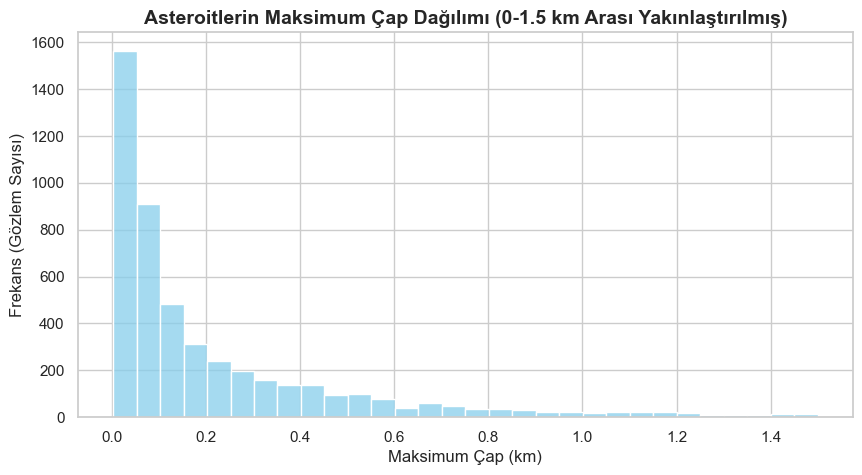

In [24]:
plt.figure(figsize=(10, 5))

#0 ile 1.5 km arasındaki veriler için
filtreli_veri =df[df["Maksimum Çap (km)"] <= 1.5]

sns.histplot(data=filtreli_veri, x="Maksimum Çap (km)", color="skyblue", bins=30)
plt.title("Asteroitlerin Maksimum Çap Dağılımı (0-1.5 km Arası Yakınlaştırılmış)", fontsize=14, fontweight="bold")
plt.xlabel("Maksimum Çap (km)", fontsize=12)
plt.ylabel("Frekans (Gözlem Sayısı)", fontsize=12)
plt.show()

### Grafik 1: Maksimum Çap Dağılımı
Uç değerlerin grafiğin eksenini bozmasını önlemek için asteriotlerin yoğunlaştığı 0 ile 1.5 km arasına odaklanarak bu histogram grafiği oluşturulmuştur. Grafikteki sütun boyları incelendiğinde, verilerin net bir şekilde **sağa çarpık (pozitif)** dağılım sergilediği görülmektedir. Asteroitlerin çoğunluğu **0.0 ile 0.2 km** arasındaki en küçük çap aralığında toplanmıştır. Çap boyutu büyüdükçe sütun boyları hızla kısalmakta ve veri sağa doğru uzun bir kuyruk oluşturmaktadır. Bu durumda veri setinde küçük asteroitlerin baskın olduğu, büyük asteroitlerin ise nadir bulunan uç değerler olduğu görselleştirilmiştir.

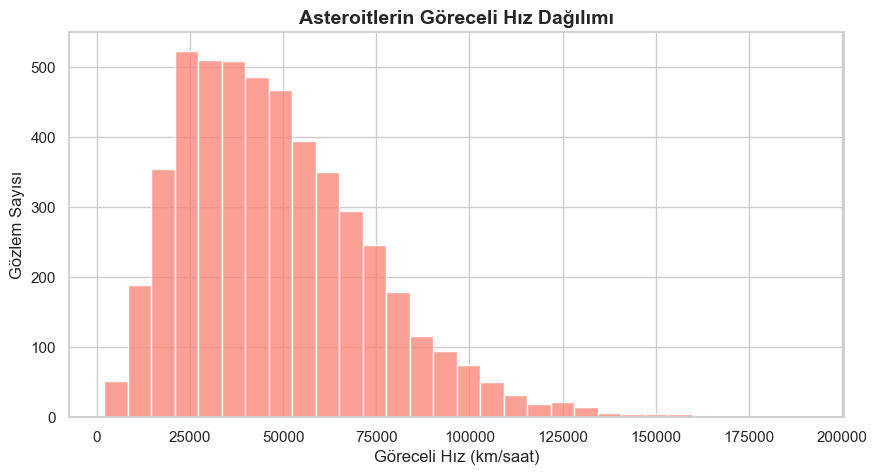

In [25]:
plt.figure(figsize=(10, 5))

# relative_velocity (Göreceli Hız (km/saat)) sütununun histogramı
sns.histplot(data=df, x="Göreceli Hız (km/saat)", color="salmon", bins=30)

plt.title("Asteroitlerin Göreceli Hız Dağılımı", fontsize=14, fontweight='bold')
plt.xlabel("Göreceli Hız (km/saat)", fontsize= 12)
plt.ylabel("Gözlem Sayısı", fontsize=12)
plt.show()

### Grafik 2: Göreceli Hız Dağılımı
Asteroitlerin göreceli hız dağılımı incelendiğimizde, çap değişkenine kıyasla çok daha dengeli ve homojen bir dağılım görülmektedir. Veride tek bir noktada aşırı kırılma yaratan uç değerler bulunmamaktadır. Grafiğin tepe noktası yaklaşık **25,000 ile 60,000 km/saat** değerleri arasında yoğunlaşmıştır. Bu durum, Dünya'nın yakınından geçen asteroitlerin çoğunun bu hız aralığında ilerlediğini göstermektedir. Dağılım, hafif bir sağa çarpıklık barındırsa da genel olarak normal dağılıma yakın bir yapıya sahiptir.

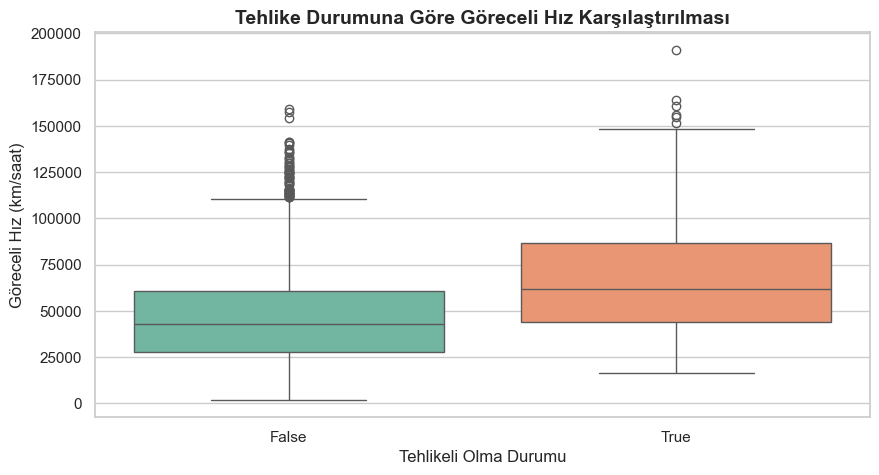

In [26]:
plt.figure(figsize=(10, 5))

# Tehlike Durumu durumuna göre hızları karşılaştıran kutu grafiği
sns.boxplot(data=df, x="Tehlike Durumu", y="Göreceli Hız (km/saat)", palette="Set2")

plt.title("Tehlike Durumuna Göre Göreceli Hız Karşılaştırılması", fontsize=14, fontweight="bold")
plt.xlabel("Tehlikeli Olma Durumu", fontsize=12)
plt.ylabel("Göreceli Hız (km/saat)", fontsize=12)
plt.show()

### Grafik 3: Tehlike Durumuna Göre Göreceli Hız Karşılaştırılması

Asteroitlerin tehlike durumları ile ilerleme hızları arasındaki ilişkiyi incelemek amacıyla kutu grafiği oluşturulmuştur. Grafik incelendiğinde, **tehlikeli asteroitlerin (True)** kutu grafiğinin, tehlikesiz olanlara (False) kıyasla daha yukarıda konumlandığı görülmektedir. Bu durum, tehlikeli asteroitlerin genel olarak daha yüksek hızlara sahip olduğunu göstermektedir. Ayrıca her iki grubun içinde de ekstrem hızlara rastlanmaktadır. Özetleyecek olursak; yüksek hız, bir asteroitin tehlike potansiyelini taşımasında önemli ve ayırt edici bir parametre öne çıkmaktadır.

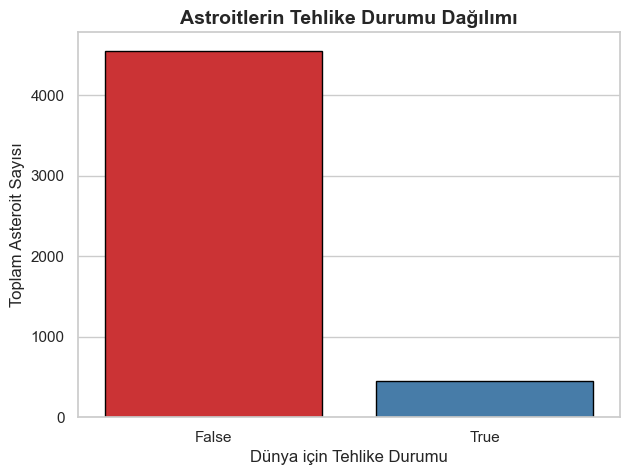

In [27]:
# Frekansları hesaplayıp kaydet.
tehlike_durumu_count = df["Tehlike Durumu"].value_counts()

# Grafik alanını oluşturma
plt.figure(figsize=(7, 5))

sns.barplot(x=tehlike_durumu_count.index, y=tehlike_durumu_count.values, palette="Set1", edgecolor="black")

plt.title("Astroitlerin Tehlike Durumu Dağılımı", fontsize=14, fontweight="bold")
plt.xlabel("Dünya için Tehlike Durumu", fontsize=12)
plt.ylabel("Toplam Asteroit Sayısı", fontsize=12)
plt.show()

### Grafik 4: Asteroitlerin Tehlike Durumu Dağılımı

Bu sütun grafiği, asteroitlerin tehlike durumlarını incelemek amacıyla oluşturulmuştur. Grafik incelendiğinde, asteroitlerin büyük çoğunluğunun "False" (Tehlikesiz) sınıfında yer aldığı görülmektedir. "True" (Tehlikeli) sınıfına ait gözlem sayısı ise oldukça düşüktür. Bu durum, veri setinde iki sınıf arasında belirgin bir dağılım farkı bulunduğunu göstermektedir.

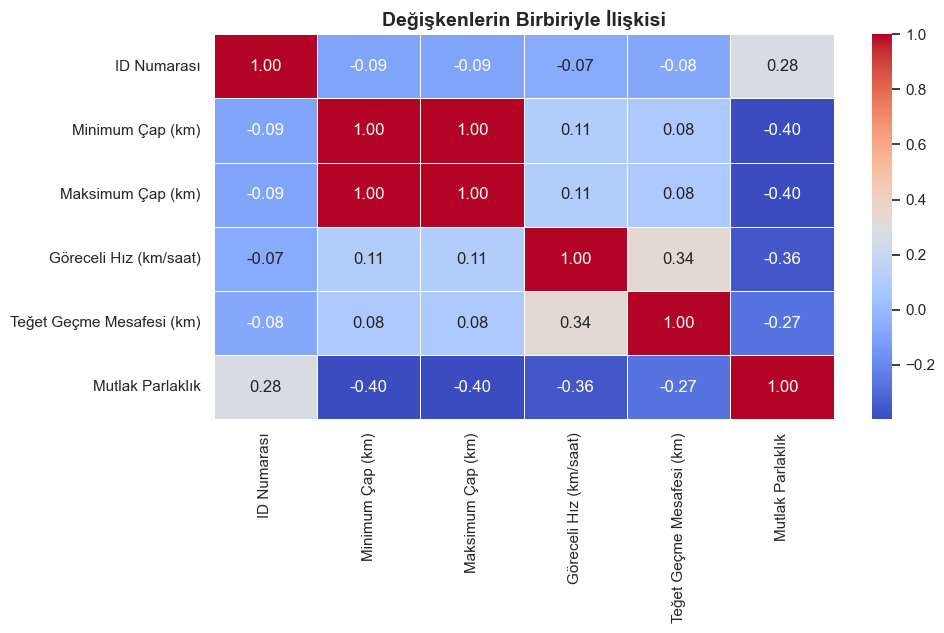

In [28]:
# Sayısal sütunları seçerek korelasyon matrisini hesaplıyoruz:
numeric_df = df.select_dtypes(include=["float64", "int64"])
corr_matrix = numeric_df.corr()

# Isı haritası oluşturma:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Değişkenlerin Birbiriyle İlişkisi", fontsize=14, fontweight="bold")
plt.show()

### Grafik 5: Değişkenlerin Birbiriyle İlişkisi

Sayısal değişkenlerin birbiriyle ilişkilerini, yönünü ve gücünü tespit etmek amacıyla Pearson Korelasyon Katsayıları hesaplanmış ve Isı Haritası üzerinde gösterilmiştir.

Grafikten elde edilen en kritik bulgular şu şekildedir:

1. **Kusursuz Pozitif Korelasyon (1.00):** Minimum çap ve maksimum çap değişkenleri arasında 1.00’lik tam bir pozitif ilişki vardır. Bu durum matematiksel olarak beklenen bir sonuçtur.
2. **Negatif Korelasyon (-0.40):** Parlaklık ile asteroit çapları arasında **-0.40** düzeyinde orta şiddette ters bir ilişki bulunmaktadır.
3. **Zayıf Pozitif Korelasyon (0.34):** Göreceli hız ile dünya’ya teğet geçme mesafesi arasında **0.34** değerinde düşük/orta düzeyde pozitif bir ilişki vardır.
4. **Anlamsız İlişkiler:** ID Numarası değişkeninin diğer değişkenlerle olan düşük korelasyonları (0.08, -0.07 vb.) tamamen anlamsızdır.

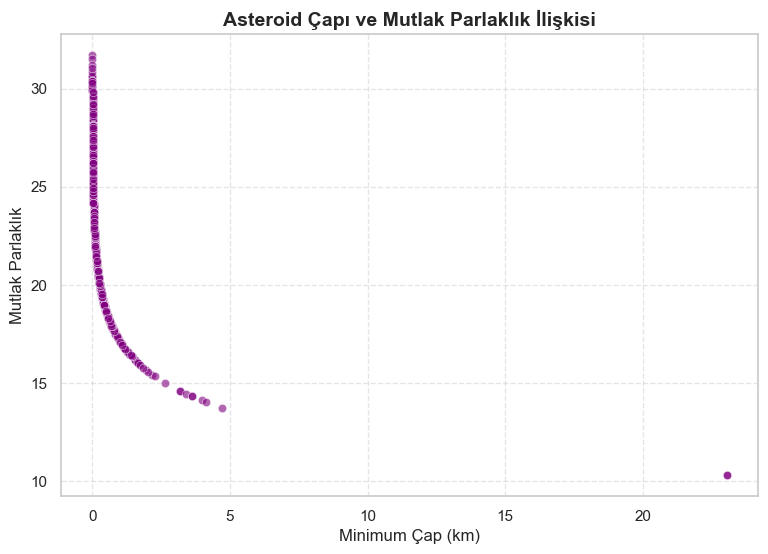

In [29]:
plt.figure(figsize=(9, 6))

# Scatter plot
sns.scatterplot(data=df, x="Minimum Çap (km)", y="Mutlak Parlaklık", color="purple", alpha=0.6)

plt.title("Asteroid Çapı ve Mutlak Parlaklık İlişkisi", fontsize=14, fontweight="bold")
plt.xlabel("Minimum Çap (km)", fontsize=12)
plt.ylabel("Mutlak Parlaklık", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Grafik 6: Asteroit Çapı ile Mutlak Parlaklık İlişkisi

İki sürekli sayısal değişken olan minimum çap (km) ile mutlak parlaklık arasında ilişkiyi geometrik olarak incelemek amacıyla bu grafik oluşturulmuştur. Grafik incelendiğinde, veri noktalarının sol üstten başlayıp sağ alta doğru net bir negatif eğri oluşturacak şekilde kümelendiği görülmektedir. İstatistikte bu durum, iki değişken arasında **doğrusal olmayan güçlü bir negatif ilişki** olduğunu göstermektedir. Astronomide parlaklık değeri küçüldükçe cismin gerçek çapı büyüdüğü için, bu negatif ilişki istatistiksel olarak da doğrudur. Ayrıca sağ altta (yaklaşık 22-23 km çapında) tek başına konumlanan veri noktası, veri setindeki ekstrem bir değeri temsil etmektedir.

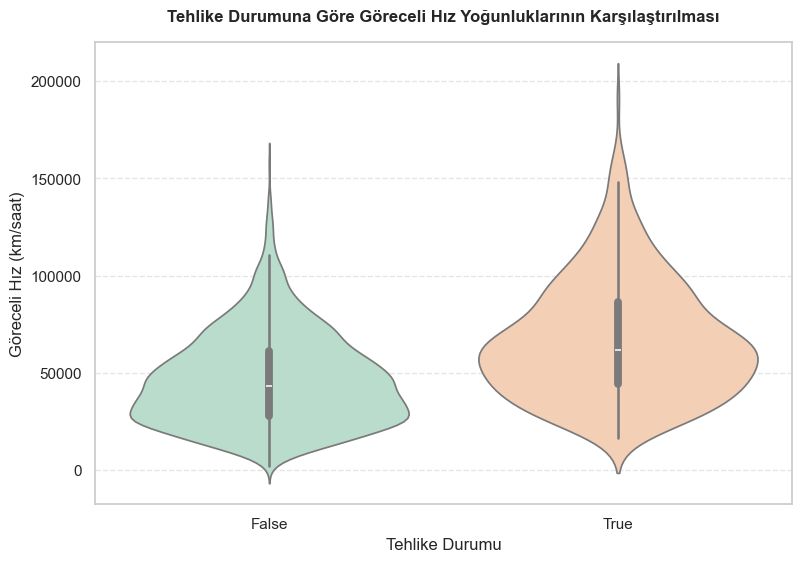

In [30]:
plt.figure(figsize=(9, 6))

sns.violinplot(x="Tehlike Durumu", y="Göreceli Hız (km/saat)", data=df, palette="Pastel2")

plt.title("Tehlike Durumuna Göre Göreceli Hız Yoğunluklarının Karşılaştırılması", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Tehlike Durumu", fontsize=12)
plt.ylabel("Göreceli Hız (km/saat)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Grafik 7: Tehlike Durumuna Göre Göreceli Hız Karşılaştırılması

İki farklı grubun sürekli bir sayısal değişken olan göreceli hız üzerindeki yoğunluk dağılımlarını ve medyanlarını karşılaştırmak amacıyla bu keman grafiği oluşturulmuştur. Grafik incelendiğinde, güvenli nesnelerin (False) alt ve orta hız seviyelerinde çok daha şişman bir gövde oluşturduğu, yani bu bölgede yoğun bir şekilde kümelendiği görülmektedir. Ayrıca, tehlikeli sınıftaki asteroitlerin (True) merkezindeki medyan çizgisi bariz şekilde daha yukarıda konumlanmakta ve dikey üst kuyruk yapısı çok daha yüksek hız seviyelerine kadar uzanmaktadır. Yapılan analiz sonuçlarının geometrik yansıması olan bu grafik, Dünya için tehdit oluşturan asteroitlerin genel olarak güvenli nesnelere kıyasla daha yüksek hızda hareket etme eğiliminde olduğunu net bir şekilde doğrulamaktadır.